# Benchmark Model Training

### Logistic Regression, Random Forest, XGBoost


## Benchmark Model Training Loop


In [1]:
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path("..").resolve()))

from helpers import ModelData
from constants import PROCESSED_DATA_FOLDER
import numpy as np

/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# comparing benchmark models with original indices

SEED = 42
np.random.seed(SEED)

model_data = ModelData.from_pickle(
    PROCESSED_DATA_FOLDER / f"processed_data_original.pkl"
)

In [3]:
# Aufteilung in business_covariates und rating_stats

# Business covariates (ohne Rating-Statistiken)
business_features = [
    "density",
    "Checkin",
    "category",
    "chain",
    "Price.Level",
    "Restaurant.Size",
    "Number.of.Seats",
    "ZRI",
    "Distance.To.City.Centre",
    "Age",
]

# Rating Statistiken
rating_features = [
    # "VAR",
    # "MEAN",
    "ENTR",
    # "COUNT",
    "COV",
    "ONE_STAR",
    "TWO_STAR",
    # "THREE_STAR",
    # "FOUR_STAR",
    # "FIVE_STAR",
    "l_COUNT",
]  # removing rating features that could be redundant

print(f"Business features: {len(business_features)} Variablen")
print(f"Rating features: {len(rating_features)} Variablen")
print(f"Gesamt: {len(business_features) + len(rating_features)} Variablen")

# Train/Test Split basierend auf train_indices
train_indices = np.arange(500)

# Eval und Calibration Indizes (beziehen sich auf den gesamten Datensatz)
eval_indices = model_data.eval_indices
calibration_indices = model_data.calibration_indices

print(f"\nTrain/Test Split:")
print(f"  Training samples: {len(train_indices)}")
print(f"  Eval samples: {len(eval_indices)}")
print(f"  Calibration samples: {len(calibration_indices)}")
print(f"  Total: {len(train_indices) + len(eval_indices) + len(calibration_indices)}")

Business features: 10 Variablen
Rating features: 5 Variablen
Gesamt: 15 Variablen

Train/Test Split:
  Training samples: 500
  Eval samples: 321
  Calibration samples: 100
  Total: 921


## Data Preprocessing (Unified Approach)


In [4]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Target Variable vorbereiten (für alle Daten)
y = model_data.benchmark_covariates["Closed"].map({"Open": 0, "Closed": 1}).values
y_train = y[train_indices]

# ============================================================================
# Unified Preprocessing: Ein Imputer + Scaler für alle Features
# ============================================================================
all_features = business_features + rating_features
categorical_cols = ["category"]
numeric_cols = [col for col in all_features if col not in categorical_cols]

# Daten vorbereiten
df_all = model_data.benchmark_covariates[all_features].copy()

# One-Hot Encoding (nur einmal!)
df_encoded = pd.get_dummies(df_all, columns=categorical_cols, drop_first=True)

# Imputation (nur auf Train-Daten fitten!)
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

# Imputer und Scaler auf Train-Daten fitten
numeric_train = df_encoded.iloc[train_indices][numeric_cols]
imputer.fit(numeric_train)
scaler.fit(imputer.transform(numeric_train))

# Imputing und Scaling auf alle Daten anwenden
numeric_data_imputed = imputer.transform(df_encoded[numeric_cols])
numeric_data = scaler.transform(numeric_data_imputed)
# numeric_data = imputer.transform(df_encoded[numeric_cols])

# Erstelle finalen DataFrame mit allen Features
df_preprocessed = pd.DataFrame(
    numeric_data, columns=numeric_cols, index=df_encoded.index
)
dummy_cols = [col for col in df_encoded.columns if col not in numeric_cols]
df_preprocessed = pd.concat([df_preprocessed, df_encoded[dummy_cols]], axis=1)


# ============================================================================
# Feature Sets: Wähle passende Spalten aus dem preprocessed DataFrame
# ============================================================================
# 1. X_mean: Nur Mean Rating (braucht kein Preprocessing)
X_mean = model_data.benchmark_covariates[["MEAN"]].values

# 2. X_business: Business Covariates (aus preprocessed DataFrame)
business_cols_numeric = [
    col for col in business_features if col not in categorical_cols
]
business_cols_dummy = [
    col for col in df_preprocessed.columns if col.startswith("category_")
]
business_cols = business_cols_numeric + business_cols_dummy
X_business = df_preprocessed[business_cols]

# 3. X_all: Alle Features (gesamter preprocessed DataFrame)
X_all = df_preprocessed

# Train Splits
X_mean_train = X_mean[train_indices]
X_business_train = X_business.iloc[train_indices]
X_all_train = X_all.iloc[train_indices]

# ============================================================================
# Zusammenfassung
# ============================================================================
print()
print("DATENVORBEREITUNGEN ABGESCHLOSSEN")
print("=" * 80)
print(f"\nTarget Variable (y):")
print(f"  Total samples: {len(y)} (Closed: {sum(y)}, Open: {len(y) - sum(y)})")
print(
    f"  Train samples: {len(y_train)} (Closed: {sum(y_train)}, Open: {len(y_train) - sum(y_train)})"
)

print(f"\nFeature Sets:")
print(f"  X_mean:     {X_mean.shape} (Train: {X_mean_train.shape})")
print(f"  X_business: {X_business.shape} (Train: {X_business_train.shape})")
print(f"  X_all:      {X_all.shape} (Train: {X_all_train.shape})")

print(f"\nFeature Details:")
print(f"  Mean Rating: 1 Variable")
print(
    f"  Business Covariates: {len(X_business.columns)} Variablen (nach One-Hot Encoding)"
)
print(f"  All Features: {len(X_all.columns)} Variablen (nach One-Hot Encoding)")


DATENVORBEREITUNGEN ABGESCHLOSSEN

Target Variable (y):
  Total samples: 921 (Closed: 225, Open: 696)
  Train samples: 500 (Closed: 119, Open: 381)

Feature Sets:
  X_mean:     (921, 1) (Train: (500, 1))
  X_business: (921, 17) (Train: (500, 17))
  X_all:      (921, 22) (Train: (500, 22))

Feature Details:
  Mean Rating: 1 Variable
  Business Covariates: 17 Variablen (nach One-Hot Encoding)
  All Features: 22 Variablen (nach One-Hot Encoding)


## Training alle Benchmark-Modelle in einer Schleife


In [5]:
# ============================================================================
# Feature Sets
# ============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from helpers import get_model_performance


# Set the number of folds for the Cross Validation
K_FOLDS = 5

feature_sets = {
    "Mean Rating": (X_mean, X_mean_train),
    "Business Cov.": (X_business, X_business_train),
    "All Features": (X_all, X_all_train),
}

# ============================================================================
# Hyperparameter Grids für GridSearchCV
# ============================================================================
# Logistic Regression Parameter
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10],
}

# Random Forest Parameter
rf_param_grid = {
    "n_estimators": [100, 200, 500],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
    "max_depth": [None, 10, 20, 30],
}

# XGBoost Parameter
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
}

# ============================================================================
# Training Loop mit GridSearchCV
# ============================================================================
results = {}
performance_data = []

print("=" * 80)
print("TRAINING BENCHMARK MODELS WITH GRID SEARCH CV")
print("=" * 80)
print(f"CV Strategy: {K_FOLDS}-Fold Cross-Validation on Training Data")
print("Scoring Metric: ROC AUC")
print("=" * 80)

for feature_name, (X, X_train) in feature_sets.items():
    print(f"\n{feature_name}:")

    # ========================================================================
    # 1. Logistic Regression with GridSearchCV
    # ========================================================================
    print(
        f"  - Training Logistic Regression with GridSearchCV...",
        end=" ",
        flush=True,
    )

    lr_model = GridSearchCV(
        LogisticRegression(random_state=SEED),
        lr_param_grid,
        cv=K_FOLDS,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=0,
    )
    lr_model.fit(X_train, y_train)
    lr_best = lr_model.best_estimator_

    y_proba_lr = lr_model.predict_proba(X)[:, 1]
    perf_lr = get_model_performance(
        y_prob=y_proba_lr,
        y_exp=y,
        calibration_indices=calibration_indices,
        eval_indices=eval_indices,
        train_indices=train_indices,
    )

    results[("Logistic Regression", feature_name)] = {
        "model": lr_best,
        "y_proba": y_proba_lr,
        "performance": perf_lr,
        "best_params": lr_model.best_params_,
        "cv_score": lr_model.best_score_,
    }

    overfitting_gap = perf_lr["in_sample_auc"] - perf_lr["auc"]

    performance_data.append(
        {
            "Model Type": "Logistic Regression",
            "Features": feature_name,
            "In-Sample AUC": perf_lr["in_sample_auc"],
            "Out-of-Sample AUC": perf_lr["auc"],
            "CV AUC": round(100 * lr_model.best_score_, 2),
            "Balanced Accuracy": perf_lr["balanced_accuracy"],
            "F1 Score": perf_lr["f1"],
            "Specificity": perf_lr["specificity"],
            "Sensitivity": perf_lr["sensitivity"],
            "Threshold": perf_lr["threshold"],
        }
    )

    print(
        f"✓ (CV: {100*lr_model.best_score_:.1f}%, OOS: {perf_lr['auc']:.1f}%, Gap: {overfitting_gap:.1f}%)"
    )
    print(f"      Best params: {lr_model.best_params_}")

    # ========================================================================
    # 2. Random Forest with GridSearchCV
    # ========================================================================
    print(f"  - Training Random Forest with GridSearchCV...", end=" ", flush=True)

    rf_model = GridSearchCV(
        RandomForestClassifier(random_state=SEED),
        rf_param_grid,
        cv=K_FOLDS,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=0,
    )
    rf_model.fit(X_train, y_train)
    rf_best = rf_model.best_estimator_

    y_proba_rf = rf_best.predict_proba(X)[:, 1]
    perf_rf = get_model_performance(
        y_prob=y_proba_rf,
        y_exp=y,
        calibration_indices=calibration_indices,
        eval_indices=eval_indices,
        train_indices=train_indices,
    )

    results[("Random Forest", feature_name)] = {
        "model": rf_best,
        "y_proba": y_proba_rf,
        "performance": perf_rf,
        "best_params": rf_model.best_params_,
        "cv_score": rf_model.best_score_,
    }

    overfitting_gap = perf_rf["in_sample_auc"] - perf_rf["auc"]

    performance_data.append(
        {
            "Model Type": "Random Forest",
            "Features": feature_name,
            "In-Sample AUC": perf_rf["in_sample_auc"],
            "Out-of-Sample AUC": perf_rf["auc"],
            "CV AUC": round(100 * rf_model.best_score_, 2),
            "Balanced Accuracy": perf_rf["balanced_accuracy"],
            "F1 Score": perf_rf["f1"],
            "Specificity": perf_rf["specificity"],
            "Sensitivity": perf_rf["sensitivity"],
            "Threshold": perf_rf["threshold"],
        }
    )

    print(
        f"✓ (CV: {100*rf_model.best_score_:.1f}%, OOS: {perf_rf['auc']:.1f}%, Gap: {overfitting_gap:.1f}%)"
    )
    print(f"      Best params: {rf_model.best_params_}")

    # ========================================================================
    # 3. XGBoost with GridSearchCV
    # ========================================================================
    print(f"  - Training XGBoost with GridSearchCV...", end=" ", flush=True)

    xgb_model = GridSearchCV(
        XGBClassifier(random_state=SEED, eval_metric="logloss"),
        xgb_param_grid,
        cv=K_FOLDS,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=0,
    )
    xgb_model.fit(X_train, y_train)
    xgb_best = xgb_model.best_estimator_

    y_proba_xgb = xgb_best.predict_proba(X)[:, 1]
    perf_xgb = get_model_performance(
        y_prob=y_proba_xgb,
        y_exp=y,
        calibration_indices=calibration_indices,
        eval_indices=eval_indices,
        train_indices=train_indices,
    )

    results[("XGBoost", feature_name)] = {
        "model": xgb_best,
        "y_proba": y_proba_xgb,
        "performance": perf_xgb,
        "best_params": xgb_model.best_params_,
        "cv_score": xgb_model.best_score_,
    }

    overfitting_gap = perf_xgb["in_sample_auc"] - perf_xgb["auc"]

    performance_data.append(
        {
            "Model Type": "XGBoost",
            "Features": feature_name,
            "In-Sample AUC": perf_xgb["in_sample_auc"],
            "Out-of-Sample AUC": perf_xgb["auc"],
            "CV AUC": round(100 * xgb_model.best_score_, 2),
            "Balanced Accuracy": perf_xgb["balanced_accuracy"],
            "F1 Score": perf_xgb["f1"],
            "Specificity": perf_xgb["specificity"],
            "Sensitivity": perf_xgb["sensitivity"],
            "Threshold": perf_xgb["threshold"],
        }
    )

    print(
        f"✓ (CV: {100*xgb_model.best_score_:.1f}%, OOS: {perf_xgb['auc']:.1f}%, Gap: {overfitting_gap:.1f}%)"
    )
    print(f"      Best params: {xgb_model.best_params_}")

print("\n" + "=" * 80)
print(
    f"TRAINING ABGESCHLOSSEN: {len(results)} Modelle trainiert mit Hyperparameter Tuning"
)
print("=" * 80)

TRAINING BENCHMARK MODELS WITH GRID SEARCH CV
CV Strategy: 5-Fold Cross-Validation on Training Data
Scoring Metric: ROC AUC

Mean Rating:
  - Training Logistic Regression with GridSearchCV... ✓ (CV: 51.9%, OOS: 50.2%, Gap: 1.7%)
      Best params: {'C': 0.01}
  - Training Random Forest with GridSearchCV... ✓ (CV: 60.7%, OOS: 54.1%, Gap: 43.9%)
      Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  - Training XGBoost with GridSearchCV... ✓ (CV: 64.3%, OOS: 55.2%, Gap: 19.7%)
      Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 7, 'n_estimators': 200, 'subsample': 0.9}

Business Cov.:
  - Training Logistic Regression with GridSearchCV... ✓ (CV: 70.6%, OOS: 71.9%, Gap: 1.6%)
      Best params: {'C': 0.01}
  - Training Random Forest with GridSearchCV... ✓ (CV: 78.5%, OOS: 82.2%, Gap: 17.7%)
      Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_s

# Comprehensive Performance Metrics

---

## Detailed performance metrics for all models

evaluation with:

- AUC
- Balanced Accuracy
- F1 Score
- Specificity
- Sensitivity
- Optimal Threshold


In [6]:
import pandas as pd

# DataFrame erstellen aus performance_data (wurde in der Training Loop erstellt)
comprehensive_performance = pd.DataFrame(performance_data)

# Nach Out-of-Sample AUC sortieren
comprehensive_performance_sorted = comprehensive_performance.sort_values(
    "Out-of-Sample AUC", ascending=False
)

print("=" * 140)
print("COMPREHENSIVE MODEL PERFORMANCE METRICS (with Hyperparameter Tuning)")
print("=" * 140)
print(comprehensive_performance_sorted.to_string(index=False))

# Bestes Modell identifizieren
best_model = comprehensive_performance_sorted.iloc[0]
print("\n" + "=" * 140)
print("BEST MODEL OVERALL (by Out-of-Sample AUC)")
print("=" * 140)
print(f"\nModel: {best_model['Model Type']} - {best_model['Features']}")
print(f"  In-Sample AUC: {best_model['In-Sample AUC']}")
print(f"  CV AUC (5-Fold): {best_model['CV AUC']}")
print(f"  Out-of-Sample AUC: {best_model['Out-of-Sample AUC']}")
print(
    f"  Overfitting Gap (In-Sample - OOS): {best_model['In-Sample AUC'] - best_model['Out-of-Sample AUC']:.2f}"
)
print(f"  Balanced Accuracy: {best_model['Balanced Accuracy']}")
print(f"  F1 Score: {best_model['F1 Score']}")
print(f"  Specificity: {best_model['Specificity']}")
print(f"  Sensitivity: {best_model['Sensitivity']}")
print(f"  Optimal Threshold: {best_model['Threshold']}")

COMPREHENSIVE MODEL PERFORMANCE METRICS (with Hyperparameter Tuning)
         Model Type      Features  In-Sample AUC  Out-of-Sample AUC  CV AUC  Balanced Accuracy  F1 Score  Specificity  Sensitivity  Threshold
            XGBoost  All Features          98.38              88.14   83.31              81.89     69.23        78.06        85.71     0.1999
      Random Forest  All Features         100.00              85.03   80.34              73.25     58.41        67.93        78.57     0.2500
            XGBoost Business Cov.          95.37              84.50   80.83              74.64     59.20        61.18        88.10     0.1437
      Random Forest Business Cov.          99.94              82.20   78.47              72.01     56.57        59.49        84.52     0.2112
Logistic Regression  All Features          80.25              79.65   75.14              73.90     60.00        76.37        71.43     0.2987
Logistic Regression Business Cov.          73.47              71.88   70.63    

In [7]:
# Overfitting Analysis
print("\n" + "=" * 140)
print("OVERFITTING ANALYSIS (In-Sample AUC - Out-of-Sample AUC)")
print("=" * 140)
overfitting_data = comprehensive_performance.copy()
overfitting_data["Overfitting Gap"] = (
    overfitting_data["In-Sample AUC"] - overfitting_data["Out-of-Sample AUC"]
)
overfitting_sorted = overfitting_data.sort_values("Overfitting Gap", ascending=True)
print(
    overfitting_sorted[
        [
            "Model Type",
            "Features",
            "In-Sample AUC",
            "CV AUC",
            "Out-of-Sample AUC",
            "Overfitting Gap",
        ]
    ].to_string(index=False)
)


OVERFITTING ANALYSIS (In-Sample AUC - Out-of-Sample AUC)
         Model Type      Features  In-Sample AUC  CV AUC  Out-of-Sample AUC  Overfitting Gap
Logistic Regression  All Features          80.25   75.14              79.65             0.60
Logistic Regression Business Cov.          73.47   70.63              71.88             1.59
Logistic Regression   Mean Rating          51.92   51.87              50.18             1.74
            XGBoost  All Features          98.38   83.31              88.14            10.24
            XGBoost Business Cov.          95.37   80.83              84.50            10.87
      Random Forest  All Features         100.00   80.34              85.03            14.97
      Random Forest Business Cov.          99.94   78.47              82.20            17.74
            XGBoost   Mean Rating          74.84   64.28              55.16            19.68
      Random Forest   Mean Rating          97.97   60.71              54.06            43.91


# Comparison with HMM Models

We load the trained HMM and VDHMM models (with specified seed) and compare them to the benchmark models.


In [8]:
from helpers import load_fitted_model

# Load HMM und VDHMM models with original indices
performance_dict_hmm_models = []

for model_name in ["hmm", "vdhmm"]:
    for S in [2, 3, 4]:
        try:
            model = load_fitted_model(model_name=model_name, S=S)

            # Extrahiere close_prob für alle Daten
            close_prob = model.fit.stan_variable("close_prob")
            close_prob_mean = close_prob.mean(axis=0)

            # Performance auf Eval-Daten mit get_model_performance
            perf_dict = get_model_performance(
                y_prob=close_prob_mean,
                y_exp=y,
                calibration_indices=calibration_indices,
                eval_indices=eval_indices,
                train_indices=train_indices,
            )

            performance_dict_hmm_models.append(
                {
                    "Model Type": model_name.upper(),
                    "Features": f"{S} States",
                    "In-Sample AUC": perf_dict["in_sample_auc"],
                    "Out-of-Sample AUC": perf_dict["auc"],
                    "Balanced Accuracy": perf_dict["balanced_accuracy"],
                    "F1 Score": perf_dict["f1"],
                    "Specificity": perf_dict["specificity"],
                    "Sensitivity": perf_dict["sensitivity"],
                    "Threshold": perf_dict["threshold"],
                }
            )

            print(f"✓ Loaded {model_name.upper()} with {S} states")

        except Exception as e:
            print(f"✗ Error loading {model_name} with {S} states: {e}")

# Konvertiere zu DataFrame
hmm_performance = pd.DataFrame(performance_dict_hmm_models)
print("\n" + "=" * 80)
print("HMM MODEL PERFORMANCE")
print("=" * 80)
print(hmm_performance.to_string(index=False))

✓ Loaded HMM with 2 states
✓ Loaded HMM with 3 states
✓ Loaded HMM with 4 states
✓ Loaded VDHMM with 2 states
✓ Loaded VDHMM with 3 states
✓ Loaded VDHMM with 4 states

HMM MODEL PERFORMANCE
Model Type Features  In-Sample AUC  Out-of-Sample AUC  Balanced Accuracy  F1 Score  Specificity  Sensitivity  Threshold
       HMM 2 States          78.49              77.27              71.70     56.43        62.45        80.95     0.2360
       HMM 3 States          81.83              82.67              75.04     60.26        67.93        82.14     0.2412
       HMM 4 States          82.45              83.62              75.15     60.83        71.73        78.57     0.2565
     VDHMM 2 States          78.46              76.84              69.63     54.25        59.49        79.76     0.2375
     VDHMM 3 States          83.92              84.40              78.08     66.30        83.54        72.62     0.3336
     VDHMM 4 States          83.24              84.77              76.65     62.01       

## Combined Performance Comparison: Benchmark vs HMM Models


In [9]:
# Kombiniere alle Modelle in einem DataFrame
all_models_performance = pd.concat(
    [comprehensive_performance, hmm_performance], ignore_index=True
)

# Sortiere nach Out-of-Sample AUC
all_models_sorted = all_models_performance.sort_values(
    "Out-of-Sample AUC", ascending=False
)

print("=" * 130)
print("ALL MODELS PERFORMANCE COMPARISON (Benchmark + HMM)")
print("=" * 130)
print(all_models_sorted.to_string(index=False))

# Identifiziere das beste Modell insgesamt
best_overall = all_models_sorted.iloc[0]
print("\n" + "=" * 130)
print("BEST MODEL OVERALL (including HMM)")
print("=" * 130)
print(f"\nModel: {best_overall['Model Type']} - {best_overall['Features']}")
print(f"  In-Sample AUC: {best_overall['In-Sample AUC']}")
print(f"  Out-of-Sample AUC: {best_overall['Out-of-Sample AUC']}")
print(f"  Balanced Accuracy: {best_overall['Balanced Accuracy']}")
print(f"  F1 Score: {best_overall['F1 Score']}")
print(f"  Specificity: {best_overall['Specificity']}")
print(f"  Sensitivity: {best_overall['Sensitivity']}")
print(f"  Optimal Threshold: {best_overall['Threshold']}")

ALL MODELS PERFORMANCE COMPARISON (Benchmark + HMM)
         Model Type      Features  In-Sample AUC  Out-of-Sample AUC  CV AUC  Balanced Accuracy  F1 Score  Specificity  Sensitivity  Threshold
            XGBoost  All Features          98.38              88.14   83.31              81.89     69.23        78.06        85.71     0.1999
      Random Forest  All Features         100.00              85.03   80.34              73.25     58.41        67.93        78.57     0.2500
              VDHMM      4 States          83.24              84.77     NaN              76.65     62.01        68.78        84.52     0.2319
            XGBoost Business Cov.          95.37              84.50   80.83              74.64     59.20        61.18        88.10     0.1437
              VDHMM      3 States          83.92              84.40     NaN              78.08     66.30        83.54        72.62     0.3336
                HMM      4 States          82.45              83.62     NaN              75.15  

In [10]:
# Vergleich: Beste HMM vs. Beste Benchmark
best_hmm = all_models_sorted[
    all_models_sorted["Model Type"].isin(["HMM", "VDHMM"])
].iloc[0]
best_benchmark = all_models_sorted[
    ~all_models_sorted["Model Type"].isin(["HMM", "VDHMM"])
].iloc[0]

print("\n" + "=" * 130)
print("BEST HMM MODEL vs. BEST BENCHMARK MODEL")
print("=" * 130)
print(f"\nBest HMM: {best_hmm['Model Type']} - {best_hmm['Features']}")
print(f"  Out-of-Sample AUC: {best_hmm['Out-of-Sample AUC']}")
print(f"  Balanced Accuracy: {best_hmm['Balanced Accuracy']}")
print(f"  F1 Score: {best_hmm['F1 Score']}")

print(
    f"\nBest Benchmark: {best_benchmark['Model Type']} - {best_benchmark['Features']}"
)
print(f"  Out-of-Sample AUC: {best_benchmark['Out-of-Sample AUC']}")
print(f"  Balanced Accuracy: {best_benchmark['Balanced Accuracy']}")
print(f"  F1 Score: {best_benchmark['F1 Score']}")

print(
    f"\nAUC Difference: {best_hmm['Out-of-Sample AUC'] - best_benchmark['Out-of-Sample AUC']:.2f} percentage points"
)


BEST HMM MODEL vs. BEST BENCHMARK MODEL

Best HMM: VDHMM - 4 States
  Out-of-Sample AUC: 84.77
  Balanced Accuracy: 76.65
  F1 Score: 62.01

Best Benchmark: XGBoost - All Features
  Out-of-Sample AUC: 88.14
  Balanced Accuracy: 81.89
  F1 Score: 69.23

AUC Difference: -3.37 percentage points


## Visualization: Benchmark vs. HMM Models


/var/folders/hc/g9ymkbv17hbdwc11nytysx7m0000gn/T/ipykernel_29920/2580730796.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


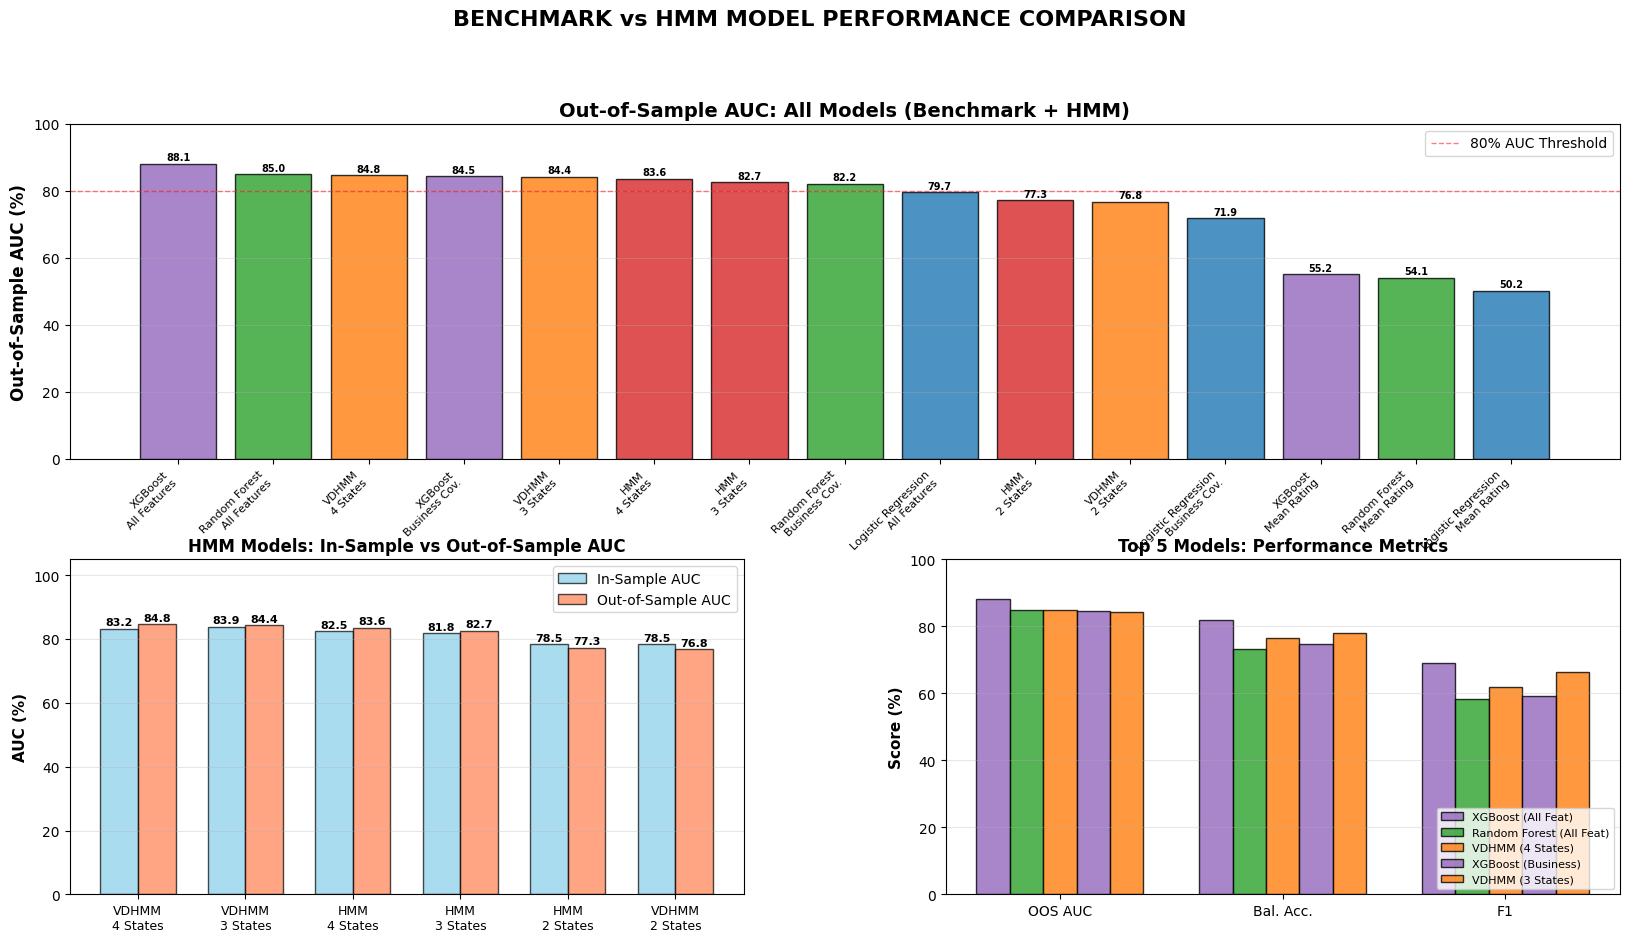

In [11]:
import matplotlib.pyplot as plt

# Erweitere das Farbschema für HMM und VDHMM
colors_map_extended = {
    "Logistic Regression": "#1f77b4",
    "Random Forest": "#2ca02c",
    "XGBoost": "#9467bd",
    "HMM": "#d62728",
    "VDHMM": "#ff7f0e",
}

# Erstelle Visualisierung
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. Out-of-Sample AUC Comparison (alle Modelle, sortiert)
ax1 = fig.add_subplot(gs[0, :])
sorted_labels = [
    f"{row['Model Type']}\n{row['Features']}" for _, row in all_models_sorted.iterrows()
]
sorted_colors = [
    colors_map_extended.get(mt, "#888888") for mt in all_models_sorted["Model Type"]
]

x_pos = np.arange(len(sorted_labels))
bars = ax1.bar(
    x_pos,
    all_models_sorted["Out-of-Sample AUC"].values,
    color=sorted_colors,
    alpha=0.8,
    edgecolor="black",
)

ax1.set_ylabel("Out-of-Sample AUC (%)", fontsize=12, fontweight="bold")
ax1.set_title(
    "Out-of-Sample AUC: All Models (Benchmark + HMM)", fontsize=14, fontweight="bold"
)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sorted_labels, fontsize=8, rotation=45, ha="right")
ax1.set_ylim([0, 100])
ax1.grid(axis="y", alpha=0.3)
ax1.axhline(
    y=80, color="red", linestyle="--", linewidth=1, alpha=0.5, label="80% AUC Threshold"
)
ax1.legend()

# Werte über Balken
for i, v in enumerate(all_models_sorted["Out-of-Sample AUC"].values):
    ax1.text(i, v + 1, f"{v:.1f}", ha="center", fontsize=7, fontweight="bold")

# 2. In-Sample vs Out-of-Sample AUC für HMM Modelle
ax2 = fig.add_subplot(gs[1, 0])
hmm_data = all_models_sorted[all_models_sorted["Model Type"].isin(["HMM", "VDHMM"])]
x_pos = np.arange(len(hmm_data))
width = 0.35

ax2.bar(
    x_pos - width / 2,
    hmm_data["In-Sample AUC"].values,
    width,
    label="In-Sample AUC",
    alpha=0.7,
    color="skyblue",
    edgecolor="black",
)
ax2.bar(
    x_pos + width / 2,
    hmm_data["Out-of-Sample AUC"].values,
    width,
    label="Out-of-Sample AUC",
    alpha=0.7,
    color="coral",
    edgecolor="black",
)

hmm_labels = [
    f"{row['Model Type']}\n{row['Features']}" for _, row in hmm_data.iterrows()
]
ax2.set_ylabel("AUC (%)", fontsize=11, fontweight="bold")
ax2.set_title(
    "HMM Models: In-Sample vs Out-of-Sample AUC", fontsize=12, fontweight="bold"
)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(hmm_labels, fontsize=9)
ax2.set_ylim([0, 105])
ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.3)

# Werte über Balken
for i, (in_val, out_val) in enumerate(
    zip(hmm_data["In-Sample AUC"].values, hmm_data["Out-of-Sample AUC"].values)
):
    ax2.text(
        i - width / 2,
        in_val + 1,
        f"{in_val:.1f}",
        ha="center",
        fontsize=8,
        fontweight="bold",
    )
    ax2.text(
        i + width / 2,
        out_val + 1,
        f"{out_val:.1f}",
        ha="center",
        fontsize=8,
        fontweight="bold",
    )

# 3. Vergleich: Top 5 Modelle
ax3 = fig.add_subplot(gs[1, 1])
top5 = all_models_sorted.head(5)
metrics = ["Out-of-Sample AUC", "Balanced Accuracy", "F1 Score"]
x = np.arange(len(metrics))
width = 0.15

for i, (idx, model) in enumerate(top5.iterrows()):
    values = [model[m] for m in metrics]
    label = f"{model['Model Type']} ({model['Features'][:8]})"
    ax3.bar(
        x + i * width,
        values,
        width,
        label=label,
        alpha=0.8,
        color=colors_map_extended.get(model["Model Type"], "#888888"),
        edgecolor="black",
    )

ax3.set_ylabel("Score (%)", fontsize=11, fontweight="bold")
ax3.set_title("Top 5 Models: Performance Metrics", fontsize=12, fontweight="bold")
ax3.set_xticks(x + width * 2)
ax3.set_xticklabels(["OOS AUC", "Bal. Acc.", "F1"], fontsize=10)
ax3.set_ylim([0, 100])
ax3.legend(fontsize=8, loc="lower right")
ax3.grid(axis="y", alpha=0.3)

plt.suptitle(
    "BENCHMARK vs HMM MODEL PERFORMANCE COMPARISON",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)

plt.tight_layout()
plt.show()